## **Predicting Medical Cost**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
import matplotlib

np.__version__, pd.__version__, sns.__version__, matplotlib.__version__

('2.0.2', '2.2.2', '0.13.2', '3.10.0')

In [3]:
df = pd.read_csv('insurance.csv')

In [4]:
# print the first rows of data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Check the shape of your data
df.shape

(1338, 7)

In [6]:
# Statistical info
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Check Dtypes of your input data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
# Check the column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## EDA

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

<Axes: xlabel='smoker', ylabel='count'>

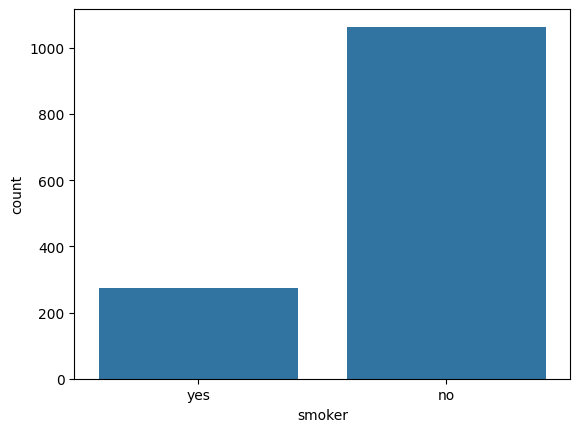

In [11]:
# Let's see how many smokers and non-smokers there are
sns.countplot(data=df, x='smoker')

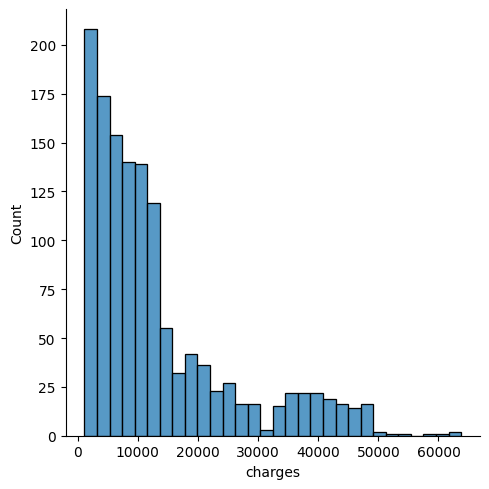

In [12]:
sns.displot(data=df, x='charges')

Text(0.5, 0, 'Smoker')

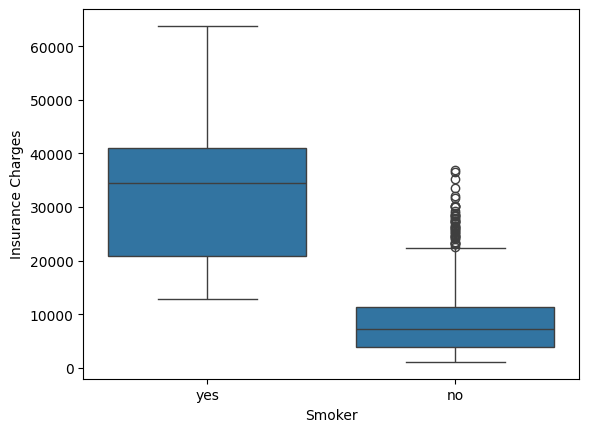

In [13]:
# Let's try boxplot on "smoker"
sns.boxplot(x=df["smoker"], y=df["charges"])
plt.ylabel("Insurance Charges")
plt.xlabel("Smoker")

<Axes: xlabel='bmi', ylabel='charges'>

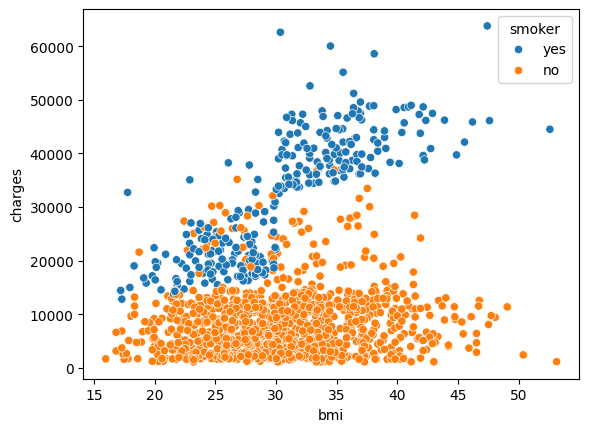

In [15]:
sns.scatterplot(x=df['bmi'], y=df['charges'], hue=df['smoker'])

In [16]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()

df["sex"] = le_sex.fit_transform(df["sex"])

df["sex"].unique()

array([0, 1])

In [17]:
le_sex.classes_

array(['female', 'male'], dtype=object)

In [18]:
le_sex.transform(["female", "male"])

array([0, 1])

In [19]:
le_smoker = LabelEncoder()

df["smoker"] = le_smoker.fit_transform(df["smoker"])

df["smoker"].unique()

array([1, 0])

In [20]:
le_smoker.classes_

array(['no', 'yes'], dtype=object)

In [21]:
le_region = LabelEncoder()

df["region"] = le_region.fit_transform(df["region"])

df["region"].unique()

array([3, 2, 1, 0])

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


<Axes: >

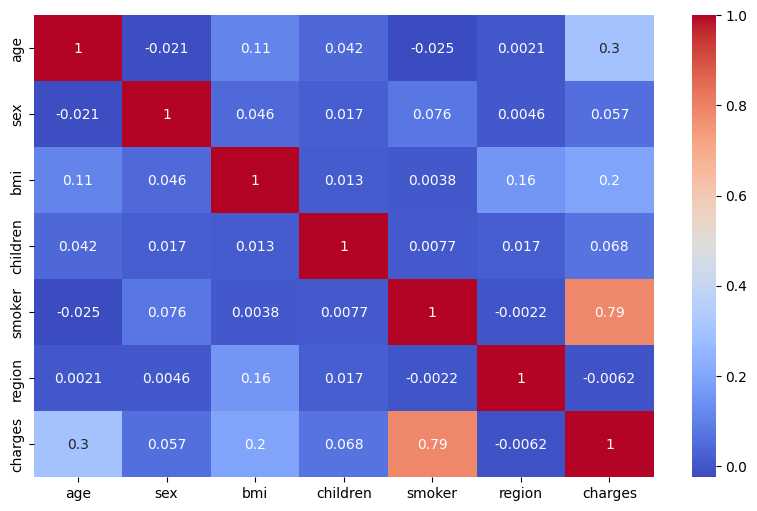

In [24]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

### We will skip feature engineering for this assignment

In [25]:
# x is our strong features
X = df[        ['smoker', 'age']        ]

# y is simply the insurance charges column
y = df["charges"]

In [26]:
X.head()

,smoker,age
0,1,19
1,0,18
2,0,28
3,0,33
4,0,32


In [27]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [29]:
X_train.shape, X_test.shape

((936, 2), (402, 2))

In [30]:
X_train.head()

,smoker,age
332,0,61
355,0,46
138,0,54
381,1,55
292,1,25


In [31]:
# check for null values
X_train[['smoker', 'age']].isna().sum()

,0
smoker,0
age,0


In [32]:
X_test[['smoker', 'age']].isna().sum()

,0
smoker,0
age,0


In [33]:
y_train.isna().sum()

np.int64(0)

In [34]:
y_test.isna().sum()

np.int64(0)

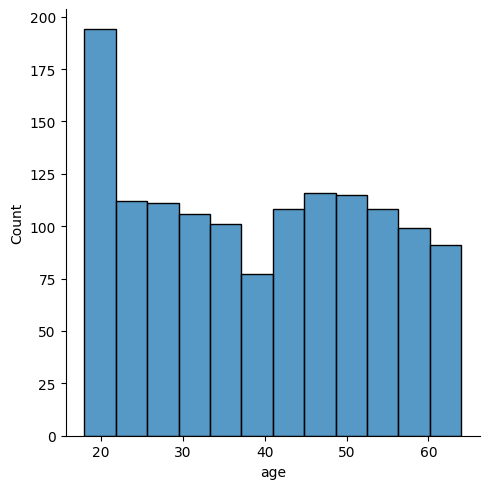

In [35]:
sns.displot(data=df, x='age')

<Axes: xlabel='smoker', ylabel='count'>

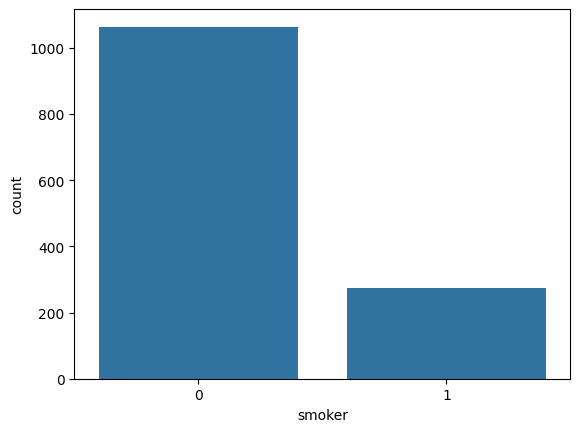

In [36]:
sns.countplot(data=df, x='smoker')

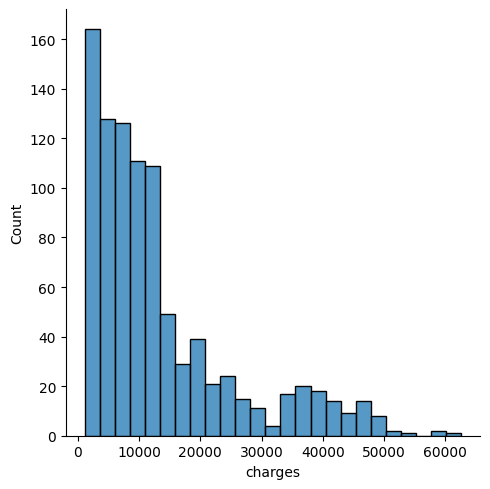

In [37]:
sns.displot(y_train)

In [38]:
# let's fill the training set first!
X_train['smoker'].fillna(X_train['smoker'].median(), inplace=True)
X_train['age'].fillna(X_train['age'].median(), inplace=True)

In [39]:
# let's fill the testing set with the training distribution first!
X_test['smoker'].fillna(X_train['smoker'].median(), inplace=True)
X_test['age'].fillna(X_train['age'].median(), inplace=True)

In [40]:
# for missing y, you don't replace them, you just delete them.
# don't forget to delete the associated x values as well

y_train_rows_with_na = y_train.isna()
y_train = y_train[~y_train_rows_with_na]
X_train = X_train[~y_train_rows_with_na]

y_test_rows_with_na = y_test.isna()
X_test = X_test[~y_test_rows_with_na]
y_test = y_test[~y_test_rows_with_na]

In [41]:
# check again
X_train[['smoker', 'age']].isna().sum()

,0
smoker,0
age,0


In [42]:
X_test[['smoker', 'age']].isna().sum()

,0
smoker,0
age,0


In [43]:
y_train.isna().sum(), y_test.isna().sum()

(np.int64(0), np.int64(0))

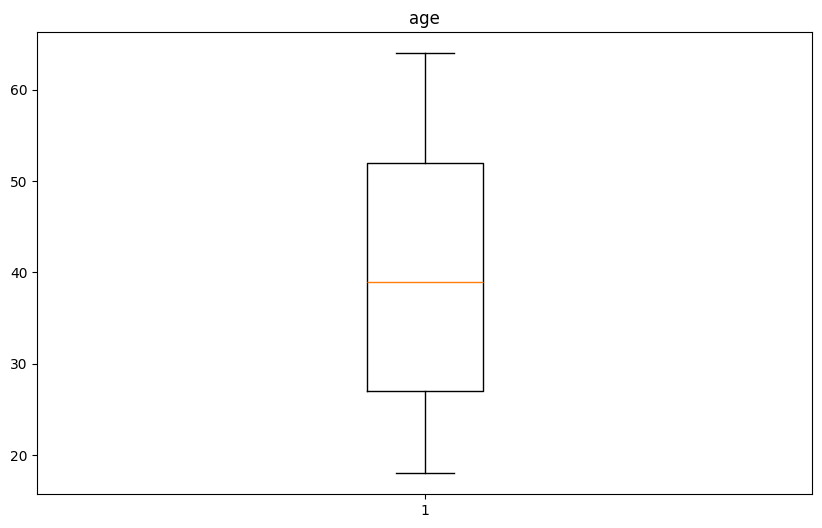

In [44]:
# Create a dictionary of continuous numerical columns
col_dict = {'age':1}

# Detect outliers using box plots
plt.figure(figsize=(10, 6))

for variable, i in col_dict.items():
    plt.subplot(1, 1, i)
    plt.boxplot(X_train[variable])
    plt.title(variable)

plt.show()

In [45]:
def outlier_count(col, data=X_train):

    # calculate your 25% quartile and 75% quartile
    q75, q25 = np.percentile(data[col], [75, 25])

    # calculate your interquartile range
    iqr = q75 - q25

    # min_val and max_val
    min_val = q25 - (iqr * 1.5)
    max_val = q75 + (iqr * 1.5)

    # count number of outliers
    outlier_count = len(
        np.where((data[col] > max_val) | (data[col] < min_val))[0]
    )

    # calculate percentage of outliers
    outlier_percent = round(outlier_count / len(data[col]) * 100, 2)

    if(outlier_count > 0):
        print("\n" + 15*'-' + col + 15*'-' + "\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [46]:
outlier_count('age')

In [47]:
from sklearn.preprocessing import StandardScaler

# feature scaling helps improve convergence
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
X_train[:5]

array([[-0.51298918,  1.54446486],
       [-0.51298918,  0.48187425],
       [-0.51298918,  1.04858924],
       [ 1.94935887,  1.11942861],
       [ 1.94935887, -1.00575261]])

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

yhat = lr.predict(X_test)

print("MSE: ", mean_squared_error(y_test, yhat))
print("r2: ", r2_score(y_test, yhat))

MSE:  37942391.93599547
r2:  0.7412271370215588


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# models that we will be using
algorithms = [
    LinearRegression(),
    SVR(),
    KNeighborsRegressor(),
    DecisionTreeRegressor(random_state = 0),
    RandomForestRegressor(n_estimators = 100, random_state = 0)
]

# names of the models
algorithm_names = [
    "Linear Regression",
    "SVR",
    "KNeighbors Regressor",
    "Decision-Tree Regressor",
    "Random-Forest Regressor"
]

In [51]:
y_train.isna().sum()

np.int64(0)

In [52]:
from sklearn.model_selection import KFold, cross_val_score

# lists for keeping mse
train_mse = []
test_mse = []

# defining splits
kfold = KFold(n_splits=5, shuffle=True)

for i, model in enumerate(algorithms):
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )

    print(f"{algorithm_names[i]} - Score: {scores}; Mean: {scores.mean()}")

Linear Regression - Score: [-39726235.83045932 -47897087.68026192 -48864804.16927271
 -32156919.18196215 -43276776.94397883]; Mean: -42384364.76118698
SVR - Score: [-1.48656910e+08 -1.69942197e+08 -1.28332467e+08 -1.73902421e+08
 -1.79020758e+08]; Mean: -159970950.45875648
KNeighbors Regressor - Score: [-61192024.63216437 -54664265.0851091  -45633875.60140314
 -46482645.86034323 -45383393.03046815]; Mean: -50671240.84189761
Decision-Tree Regressor - Score: [-57488101.73410393 -42166445.40794579 -63208062.1685464
 -66085457.08800729 -50559348.87926572]; Mean: -55901483.055573836
Random-Forest Regressor - Score: [-58691922.13998539 -41946368.66613366 -61653362.05332261
 -49107440.53843393 -57780564.70043226]; Mean: -53835931.61966157


In [56]:
best_mse

np.float64(-45779586.82337194)

In [60]:
mean_squared_error(y_test, yhat)

38220879.36094536

In [61]:
r2_score(y_test, yhat)

0.7393278105800591

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

param_grid_lr = {
    'fit_intercept': [True, False]
}

lr = LinearRegression()

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=kfold,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
    scoring='neg_mean_squared_error'
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=True),
             estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [65]:
grid_lr.best_params_

{'fit_intercept': True}

In [66]:
-grid_lr.best_score_

np.float64(42518864.36956711)

In [67]:
yhat = grid_lr.predict(X_test)

mean_squared_error(y_test, yhat)

37942391.93599547

In [68]:
r2_score(y_test, yhat)

0.7412271370215588

In [69]:
# Store the best Linear Regression model
lr_best = grid_lr.best_estimator_

lr_best.coef_

array([9610.9767936 , 3942.17496124])

In [70]:
for feature, coefficient in zip(X.columns, lr_best.coef_):
    print(feature, ":", coefficient)

smoker : 9610.976793597512
age : 3942.1749612357185


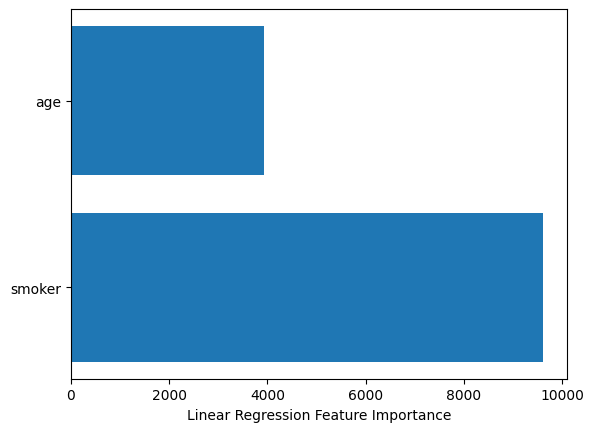

In [71]:
plt.barh(X.columns, np.abs(lr_best.coef_))
plt.xlabel("Linear Regression Feature Importance")
plt.show()

In [73]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    lr_best,
    X_test,
    y_test,
    random_state=42
)

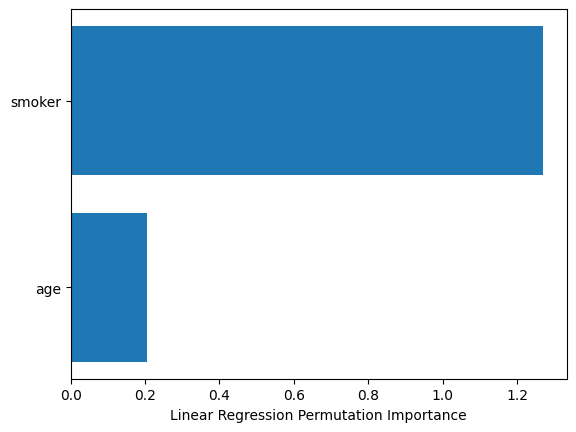

In [74]:
sorted_idx = perm_importance.importances_mean.argsort()

plt.barh(
    X.columns[sorted_idx],
    perm_importance.importances_mean[sorted_idx]
)

plt.xlabel("Linear Regression Permutation Importance")
plt.show()

In [75]:
import shap

explainer = shap.LinearExplainer(lr_best, X_train)

shap_values = explainer.shap_values(X_test)

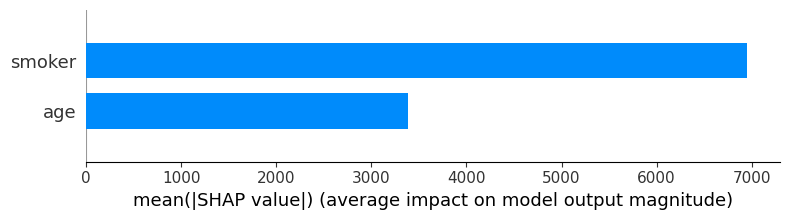

In [76]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=X.columns
)

In [77]:
import pickle
import os

# create model folder if it does not exist
os.makedirs('model', exist_ok=True)

# save the model to disk
filename = 'model/insurance.model'
pickle.dump(grid_lr, open(filename, 'wb'))

In [78]:
scaler_filename = 'model/insurance_scaler.pkl'
pickle.dump(scaler, open(scaler_filename, 'wb'))

In [79]:
# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))

# load the scaler
loaded_scaler = pickle.load(open(scaler_filename, 'rb'))

In [80]:
df[['smoker', 'age', 'charges']].loc[1]

,1
smoker,0.0000
age,18.0000
charges,1725.5523


In [81]:
sample = pd.DataFrame(
    [[1, 40]],
    columns=['smoker', 'age']
)

sample

,smoker,age
0,1,40


In [82]:
sample_scaled = loaded_scaler.transform(sample)

sample_scaled

array([[1.94935887, 0.056838  ]])

In [83]:
predicted_charge = loaded_model.predict(sample_scaled)

predicted_charge

array([32338.46550711])

In [85]:
print(f"Predicted Insurance Charge: ${predicted_charge[0]:.2f}")

Predicted Insurance Charge: $32338.47


## Conclusion
This insurance dataset is a regression problem because we are trying to predict charges, which is a number. The dataset has 1,338 rows, 6 input features, and 1 target (charges). Some columns like sex, smoker, and region are text, so pandas shows them as object. We changed these text values into numbers using label encoding. One-hot encoding is another option where each category gets its own column. We used graphs like countplots, distribution plots, boxplots, and scatterplots to understand the data. For missing values, we can use the mean when the data is fairly balanced, but the median is usually better when the data is skewed or has outliers. We also scaled the data so the features are on a similar scale. We split the data before preprocessing to avoid data leakage, and random_state=42 makes sure we get the same train-test split every time.
We compared several models using 5-fold cross-validation, including Linear Regression, SVR, KNN, Decision Tree, and Random Forest. For our insurance data, Linear Regression performed the best because it had the lowest MSE, meaning its predictions were closer to the real insurance charges. There is no fixed MSE that is always good or bad, so we compare it with other models on the same dataset; lower is better. We can also try different combinations of features, such as smoker, age, and bmi, to see if the MSE improves. Cross-validation helps us choose the best model, while Grid Search helps us find the best settings for that model. During both cross-validation and Grid Search, we only use the training data and keep the test data untouched until the final evaluation.